### Pipeline di preprocessing

- **1. Acquisizione del segnale audio**

Facciamo tutti gli import:

In [1]:
import datasets
import librosa
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd

/opt/miniconda3/envs/tirocinio/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ora acquisiamo il segnale audio. Usiamo il dataset Librispeech, che è un dataset ampiamente utilizzato per il riconoscimento vocale. Per il momento uso il set di validation in streaming

In [2]:
print("Connessione a librispeech...")
ds = datasets.load_dataset("librispeech_asr", "clean", split="validation", streaming=True)
example = next(iter(ds))
print("Caricato!")
print(example.keys())
print(example["audio"].keys())

Connessione a librispeech...
Caricato!
dict_keys(['file', 'audio', 'text', 'speaker_id', 'chapter_id', 'id'])
dict_keys(['path', 'array', 'sampling_rate'])


In [5]:

subset = list(ds.take(10))

Normalizziamo l'audio tra -1 e 1:

In [4]:
for example in subset:
    example["audio"]["array"] = librosa.util.normalize(example["audio"]["array"])

all_samples = np.concatenate([ex["audio"]["array"] for ex in subset])

print(f"Min: {all_samples.min()}, Max: {all_samples.max()}")
assert np.max(np.abs(all_samples)) <= 1.0 + 1e-6

Min: -1.0, Max: 0.994986750698274


Da qui possiamo applicare il log-mel-spectrogram

Text(0.5, 1.0, 'Mel spectrogram')

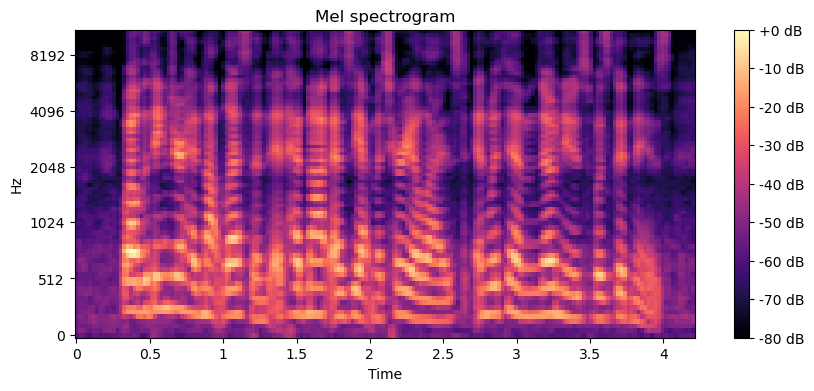

In [ ]:
spec = librosa.power_to_db(librosa.feature.melspectrogram(y=example["audio"]["array"], sr=16000, n_mels=80), ref=np.max)
plt.figure(figsize=(10, 4))
librosa.display.specshow(spec, y_axis="mel", x_axis="time")
plt.colorbar(format="%+2.0f dB")
plt.title("Mel spectrogram")

Ora lo calcolo per tutti, facendo anche normalizzazione con media 0 e varianza unitaria:

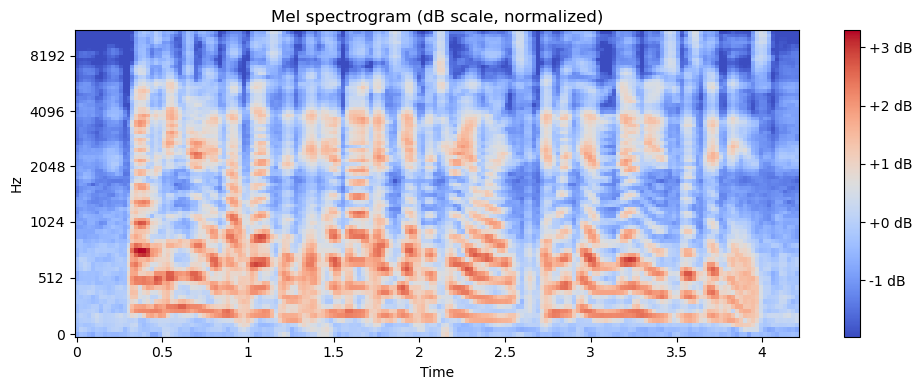

In [15]:
for row in subset:
    spec = librosa.feature.melspectrogram(y=row["audio"]["array"], sr=16000, n_mels=80)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    mean, std = spec_db.mean(), spec_db.std()
    row["mel_spectrogram"] = (spec_db - mean) / (std + 1e-8)


plt.figure(figsize=(10, 4))
librosa.display.specshow(example["mel_spectrogram"], y_axis="mel", x_axis="time")
plt.colorbar(format="%+2.0f dB")
plt.title("Mel spectrogram (dB scale, normalized)")
plt.tight_layout()

Facciamo un po' di considerazioni sulla scala mel. Essa è una scala logaritmica che riflette la percezione umana del suono. Le frequenze più basse sono rappresentate con maggiore dettaglio, mentre le frequenze più alte sono compresse. Questo è utile per il riconoscimento vocale, poiché la maggior parte delle informazioni rilevanti si trova nelle frequenze più basse.
Con librosa.feature.melspectrogram ogni audio è una matrice FxT,  dove T è il numero di frame temporali ed F il numero di bande di Mel

In [10]:
example["mel_spectrogram"].shape

(80, 182)

Ora costruiamo un dizionario che contiene come chiave le lettere e la punteggiatura, e assegnamo a ognuno di questi un numero.

In [11]:
import string

CHARS = string.ascii_uppercase + "!?.,;:'\"- "  # A-Z + punteggiatura + spazio
char_to_index = {char: idx for idx, char in enumerate(CHARS)}
char_to_index

{'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'J': 9,
 'K': 10,
 'L': 11,
 'M': 12,
 'N': 13,
 'O': 14,
 'P': 15,
 'Q': 16,
 'R': 17,
 'S': 18,
 'T': 19,
 'U': 20,
 'V': 21,
 'W': 22,
 'X': 23,
 'Y': 24,
 'Z': 25,
 '!': 26,
 '?': 27,
 '.': 28,
 ',': 29,
 ';': 30,
 ':': 31,
 "'": 32,
 '"': 33,
 '-': 34,
 ' ': 35}

Per ultimo aggiungiamo alla pipeline di preprocessing la conversione del testo in sequenze di indici, usando il dizionario che abbiamo appena creato. In questo modo, ogni parola sarà rappresentata come una sequenza di numeri, che potrà essere utilizzata come input per il modello di riconoscimento vocale.

In [13]:
for row in subset:
    text = row["text"]
    row["text_indices"] = [char_to_index[char] for char in text if char in char_to_index]
print(example["text"])
print(example["text_indices"])
ipd.Audio(example["audio"]["array"], rate=16000)

WHILE THE DANGER HAD NOT LESSENED IT HAD NOT AS YET MATERIALISED AND WITH HIM NO NEWS WAS GOOD NEWS
[22, 7, 8, 11, 4, 35, 19, 7, 4, 35, 3, 0, 13, 6, 4, 17, 35, 7, 0, 3, 35, 13, 14, 19, 35, 11, 4, 18, 18, 4, 13, 4, 3, 35, 8, 19, 35, 7, 0, 3, 35, 13, 14, 19, 35, 0, 18, 35, 24, 4, 19, 35, 12, 0, 19, 4, 17, 8, 0, 11, 8, 18, 4, 3, 35, 0, 13, 3, 35, 22, 8, 19, 7, 35, 7, 8, 12, 35, 13, 14, 35, 13, 4, 22, 18, 35, 22, 0, 18, 35, 6, 14, 14, 3, 35, 13, 4, 22, 18]
